Path to dataset files: C:\Users\rkmoh\.cache\kagglehub\datasets\jamaltariqcheema\pima-indians-diabetes-dataset\versions\1


In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [21]:
df=pd.read_csv(r"diabetes.csv")

In [22]:
import tensorflow as tf

In [24]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [26]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
df.drop_duplicates(inplace=True)

In [31]:
import seaborn as sns 
x=df.drop('Outcome',axis=1)
y=df['Outcome']

<Axes: xlabel='Age'>

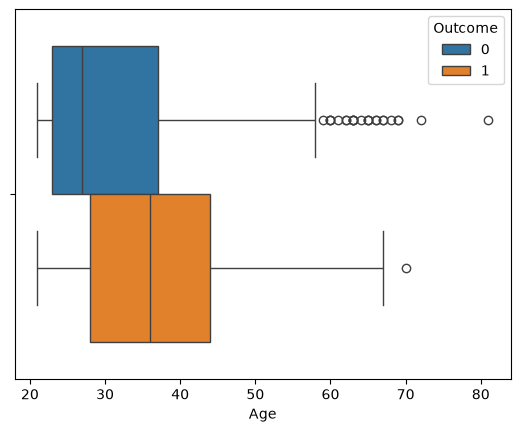

In [153]:
sns.boxplot(x=df['Age'],hue=df['Outcome'])

In [39]:
df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.495990
BloodPressure               0.174469
SkinThickness               0.295138
Insulin                     0.377081
BMI                         0.315577
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [44]:
scale=StandardScaler()

In [46]:
x_scaleed=scale.fit_transform(x)
x.shape

(768, 8)

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x_scaleed,y,test_size=0.2,random_state=42)

In [50]:
x_train

array([[-0.54791859, -1.23757346, -0.19749482, ..., -0.33953311,
        -0.50700636, -1.04154944],
       [ 1.53084665, -0.31786169,  0.79439196, ..., -0.61585588,
         2.44666971,  1.4259954 ],
       [-0.84488505,  0.56900323, -2.18126837, ..., -0.54313936,
         0.55003518, -0.95646168],
       ...,
       [ 1.82781311, -0.67917703,  1.12502089, ...,  1.91467893,
         2.00573238,  0.40494237],
       [-1.14185152,  0.63469692,  0.17446272, ...,  1.44929322,
        -0.8059981 , -0.36084741],
       [-1.14185152,  0.10914734,  1.9515932 , ..., -1.44482418,
        -0.63385134, -1.04154944]], shape=(614, 8))

In [154]:
import tensorflow 
from tensorflow import keras
from keras import Sequential 
from keras.layers import Dense
from keras.layers import Dropout


In [58]:
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=8))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [63]:

model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8078 - loss: 0.3825 - val_accuracy: 0.7662 - val_loss: 0.4347
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8127 - loss: 0.3796 - val_accuracy: 0.7727 - val_loss: 0.4331
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8127 - loss: 0.3770 - val_accuracy: 0.7792 - val_loss: 0.4340
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8160 - loss: 0.3746 - val_accuracy: 0.7857 - val_loss: 0.4325
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8208 - loss: 0.3717 - val_accuracy: 0.7922 - val_loss: 0.4328
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8241 - loss: 0.3692 - val_accuracy: 0.7987 - val_loss: 0.4314
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8306 - loss: 0.3663 - val_accuracy: 0.8052 - val_loss: 0.4314
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8306 - loss: 0.3635 - val_accuracy: 0.8117 - v

In [73]:
# 1:how to select appropriate optimizer
#2:no of nodes in ao of  layer
#3: how to select no of layers
#4:all in one model

In [74]:
import kerastuner as kt

In [82]:
def build_model(hp):
    model=Sequential()
    model.add(Dense(32,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=hp.Choice('optimizer',values=['adam','sgd','rmsprop']),loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [91]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='my_model'
)

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    verbose=1
)

Trial 3 Complete [00h 00m 02s]
val_accuracy: 0.7597402334213257

Best val_accuracy So Far: 0.8051947951316833
Total elapsed time: 00h 00m 06s


In [93]:
tuner.results_summary()

Results summary
Results in tuner_dir\my_model
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
optimizer: rmsprop
Score: 0.8051947951316833

Trial 1 summary
Hyperparameters:
optimizer: adam
Score: 0.7727272510528564

Trial 2 summary
Hyperparameters:
optimizer: sgd
Score: 0.7597402334213257


# get best parameter

In [94]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

# get best model


In [95]:
model=tuner.get_best_models(num_models=1)[0]

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(store)


In [96]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
model.fit(x_train,y_train,batch_size=32,epochs=100,initial_epoch=6,validation_data=(x_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7834 - loss: 0.4655 - val_accuracy: 0.8052 - val_loss: 0.4740
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7834 - loss: 0.4549 - val_accuracy: 0.8052 - val_loss: 0.4681
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7850 - loss: 0.4486 - val_accuracy: 0.8052 - val_loss: 0.4636
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7932 - loss: 0.4430 - val_accuracy: 0.8117 - val_loss: 0.4598
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7915 - loss: 0.4388 - val_accuracy: 0.8052 - val_loss: 0.4584
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7915 - loss: 0.4345 - val_accuracy: 0.8052 - val_loss: 0.4569
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7964 - loss: 0.4313 - val_accuracy: 0.8117 - val_loss: 0.4556
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7948 - loss: 0.4276 - val_accuracy: 0.81

In [113]:
def  build_model2(hp):
    model=Sequential()
    units=hp.Int("units",min_value=8,max_value=128,step=8)
    model.add(Dense(units=units,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [118]:
tuner2 = kt.RandomSearch(
    build_model2,
    objective="val_accuracy",
    max_trials=5,
    directory="tuner_dir",
    project_name="units_test",
    overwrite=True
)

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [119]:
tuner2.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    verbose=1
)

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.7337662577629089

Best val_accuracy So Far: 0.8051947951316833
Total elapsed time: 00h 00m 14s


In [120]:
tuner2.results_summary()

Results summary
Results in tuner_dir\units_test
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
units: 128
Score: 0.8051947951316833

Trial 2 summary
Hyperparameters:
units: 48
Score: 0.8051947951316833

Trial 3 summary
Hyperparameters:
units: 104
Score: 0.7792207598686218

Trial 0 summary
Hyperparameters:
units: 112
Score: 0.7662337422370911

Trial 4 summary
Hyperparameters:
units: 16
Score: 0.7337662577629089


In [122]:
tuner2.get_best_hyperparameters()[0].values

{'units': 128}

In [124]:
model2=tuner2.get_best_models(num_models=1)[0]

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(store)


In [125]:
model2.fit(x_train,y_train,batch_size=32,epochs=100,initial_epoch=6,validation_data=(x_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7932 - loss: 0.4405 - val_accuracy: 0.8052 - val_loss: 0.4348
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7980 - loss: 0.4224 - val_accuracy: 0.8182 - val_loss: 0.4314
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7980 - loss: 0.4128 - val_accuracy: 0.8052 - val_loss: 0.4289
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7964 - loss: 0.4049 - val_accuracy: 0.8052 - val_loss: 0.4287
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8046 - loss: 0.3976 - val_accuracy: 0.8117 - val_loss: 0.4244
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8094 - loss: 0.3900 - val_accuracy: 0.8117 - val_loss: 0.4215
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8192 - loss: 0.3846 - val_accuracy: 0.8182 - val_loss: 0.4194
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8176 - loss: 0.3787 - val_accuracy

# how to select no of layers

In [ ]:
def build_model3(hp):

    model = Sequential()

    model.add(Dense(128, activation='relu', input_dim=8))

    for _ in range(hp.Int('num_layer', min_value=1, max_value=10)):
        model.add(Dense(72, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [137]:
tuner3 = kt.RandomSearch(
    build_model3,
    objective='val_accuracy',
    max_trials=3,
    directory='tuner3_dir',
    project_name='layer_test',
    overwrite=True
)

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
tuner3.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    verbose=1
)

Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.8441558480262756

Best val_accuracy So Far: 0.850649356842041
Total elapsed time: 00h 00m 11s


In [139]:
tuner3.results_summary()

Results summary
Results in tuner3_dir\layer_test
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
num_layer: 6
Score: 0.850649356842041

Trial 2 summary
Hyperparameters:
num_layer: 5
Score: 0.8441558480262756

Trial 1 summary
Hyperparameters:
num_layer: 1
Score: 0.8311688303947449


In [140]:
tuner3.get_best_hyperparameters()[0].values

{'num_layer': 6}

In [141]:
model=tuner3.get_best_models(num_models=1)[0]

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(store)


In [142]:
model.fit(x_train,y_train,epochs=100,initial_epoch=6,validation_data=(x_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8616 - loss: 0.3264 - val_accuracy: 0.8182 - val_loss: 0.4601
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8974 - loss: 0.2759 - val_accuracy: 0.8377 - val_loss: 0.4644
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8876 - loss: 0.2697 - val_accuracy: 0.8312 - val_loss: 0.4647
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9202 - loss: 0.2388 - val_accuracy: 0.7922 - val_loss: 0.5597
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9153 - loss: 0.2343 - val_accuracy: 0.8117 - val_loss: 0.5461
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9088 - loss: 0.2309 - val_accuracy: 0.8442 - val_loss: 0.5184
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9267 - loss: 0.2071 - val_accuracy: 0.8117 - val_loss: 0.6292
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9218 - loss: 0.2072 - val_accuracy:

# all in one 


In [155]:
def build_model4(hp):
    model=Sequential()
    counter=0
    units=hp.Int('units',min_value=8,max_value=128,step=3)
    for i in range(hp.Int("num_layers",min_value=1,max_value=10)):
        if counter== 0:
            model.add(
                Dense(
                    hp.Int('units'+str(i)
                           ,min_value=8,
                           max_value=128,
                           step=8),
                           activation=hp.Choice("activation"+str(i),values=['relu','tanh','sigmoid']),
                           input_dim=8 ))
            model.add(Dropout(hp.Choice("droput"+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        else:
             model.add(
                            Dense(
                                hp.Int('units'+str(i)
                                       ,min_value=8,
                                       max_value=128,
                                       step=8),
                                       activation=hp.Choice("activation"+str(i),values=['relu','tanh','sigmoid'])
                                        ))
             model.add(Dropout(hp.Choice("droput"+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
 
        counter+=1
    model.add(Dense(1,activation='sigmoid'))   
    model.compile(optimizer=hp.Choice('optimizer',values=['adam','sgd','rmsprop']),loss='binary_crossentropy',metrics=['accuracy'])
    return model
      

In [156]:
tuner4=kt.RandomSearch(build_model4,
                       objective='val_accuracy',
                       max_trials=6,
                       directory='tuner4_dir',
                       project_name='all_test',
                       overwrite=True)

c:\Users\rkmoh\anaconda3\envs\sih\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [157]:
tuner4.search(x_train,y_train,epochs=6,validation_data=(x_test,y_test),verbose=1)

Trial 6 Complete [00h 00m 06s]
val_accuracy: 0.6428571343421936

Best val_accuracy So Far: 0.6428571343421936
Total elapsed time: 00h 00m 37s


In [158]:
tuner4.results_summary()

Results summary
Results in tuner4_dir\all_test
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
units: 107
num_layers: 5
units0: 24
activation0: sigmoid
droput0: 0.7
optimizer: sgd
units1: 8
activation1: relu
droput1: 0.1
units2: 8
activation2: relu
droput2: 0.1
units3: 8
activation3: relu
droput3: 0.1
units4: 8
activation4: relu
droput4: 0.1
Score: 0.6428571343421936

Trial 1 summary
Hyperparameters:
units: 122
num_layers: 8
units0: 16
activation0: sigmoid
droput0: 0.8
optimizer: adam
units1: 104
activation1: sigmoid
droput1: 0.1
units2: 8
activation2: relu
droput2: 0.7
units3: 64
activation3: sigmoid
droput3: 0.8
units4: 96
activation4: sigmoid
droput4: 0.6
units5: 8
activation5: relu
droput5: 0.1
units6: 8
activation6: relu
droput6: 0.1
units7: 8
activation7: relu
droput7: 0.1
Score: 0.6428571343421936

Trial 2 summary
Hyperparameters:
units: 83
num_layers: 9
units0: 128
activation0: sigmoid
droput0: 0.1
optimizer: rmsprop
unit

In [159]:
tuner4.get_best_hyperparameters()[0].values

{'units': 107,
 'num_layers': 5,
 'units0': 24,
 'activation0': 'sigmoid',
 'droput0': 0.7,
 'optimizer': 'sgd',
 'units1': 8,
 'activation1': 'relu',
 'droput1': 0.1,
 'units2': 8,
 'activation2': 'relu',
 'droput2': 0.1,
 'units3': 8,
 'activation3': 'relu',
 'droput3': 0.1,
 'units4': 8,
 'activation4': 'relu',
 'droput4': 0.1}

In [160]:
model=tuner4.get_best_models(num_models=1)[0]


In [161]:
model.fit(x_train,y_train,epochs=100,initial_epoch=6,validation_data=(x_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4984 - loss: 0.7053 - val_accuracy: 0.6429 - val_loss: 0.6795
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5847 - loss: 0.6907 - val_accuracy: 0.6429 - val_loss: 0.6753
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6124 - loss: 0.6798 - val_accuracy: 0.6429 - val_loss: 0.6715
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5912 - loss: 0.6826 - val_accuracy: 0.6429 - val_loss: 0.6684
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6221 - loss: 0.6739 - val_accuracy: 0.6429 - val_loss: 0.6656
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6287 - loss: 0.6726 - val_accuracy: 0.6429 - val_loss: 0.6633
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6498 - loss: 0.6643 - val_accuracy: 0.6429 - val_loss: 0.6616
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6515 - loss: 0.6626 - val_accuracy: 0